# Perbandingan Metode Enhancement Palmprint

Notebook ini membandingkan 4 pendekatan enhancement untuk preprocessing palmprint:
1. **dog_only (ORIGINAL)** - versi yang sedang dipakai di production
2. **dog_only (FIXED)** - perbaikan sigma DoG + bilateral filter
3. **without_gabor** - black-hat morphology multi-scale
4. **enhance_gabor** - Gabor filter bank multi-scale & multi-orientasi

Ganti  di cell load gambar sesuai lokasi ROI kamu sendiri.

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi (sama dengan extractor.py)
ROI_SIZE = 200
IMAGE_SIZE = 96
CLAHE_CLIP = 2.0
CLAHE_TILE = (8, 8)
GABOR_GAMMA = 0.5
GABOR_THETAS = [i * np.pi / 8 for i in range(8)]
GABOR_SCALES = [
    (21, 1.5, 5.0),
    (31, 2.0, 8.0),
    (31, 3.0, 12.0),
    (31, 4.0, 16.0),
]

In [16]:
# ============================================================
# VERSI ORIGINAL (persis dari kode kamu)
# ============================================================
def normalize_illumination_original(img_gray):
    img_f = img_gray.astype(np.float32)
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=0.5)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=12.0)
    dog = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_dog_only_original(img_gray):
    dog = normalize_illumination_original(img_gray)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_out = clahe.apply(dog)
    clahe_out = cv2.bitwise_not(clahe_out)
    gamma = 1.8
    lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    result = cv2.LUT(clahe_out, lut)
    blur = cv2.GaussianBlur(result, (0, 0), sigmaX=1.0)
    result = cv2.addWeighted(result, 1.4, blur, -0.4, 0)
    return result

In [17]:
# ============================================================
# VERSI FIXED - sigma DoG dinaikkan, CLAHE clip diturunkan,
# tambah bilateral filter, unsharp dikurangi
# ============================================================
def normalize_illumination_fixed(img_gray):
    img_f = img_gray.astype(np.float32)
    # sigma kecil dinaikkan dari 0.5 -> 1.5 supaya noise sub-piksel
    # ter-blur dulu sebelum displit dari background
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=1.5)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=12.0)
    dog = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_dog_only_fixed(img_gray):
    dog = normalize_illumination_fixed(img_gray)

    # clip diturunkan dari 2.0 -> 1.5 supaya tidak double-enhance noise
    clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
    clahe_out = clahe.apply(dog)

    # bilateral filter SEBELUM invert/gamma - bersihkan speckle,
    # pertahankan tepi garis (ini yang HILANG di versi original)
    clahe_out = cv2.bilateralFilter(clahe_out, d=5, sigmaColor=25, sigmaSpace=25)

    clahe_out = cv2.bitwise_not(clahe_out)
    gamma = 1.8
    lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    result = cv2.LUT(clahe_out, lut)

    # unsharp amount dikurangi dari 1.4 -> 1.2
    blur = cv2.GaussianBlur(result, (0, 0), sigmaX=1.0)
    result = cv2.addWeighted(result, 1.2, blur, -0.2, 0)
    return result

In [18]:
# ============================================================
# without_gabor (dari kode kamu, pakai DoG fixed)
# ============================================================
def enhance_without_gabor(img_gray):
    dog = normalize_illumination_fixed(img_gray)

    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))

    blackhat_small = cv2.morphologyEx(dog, cv2.MORPH_BLACKHAT, kernel_small)
    blackhat_large = cv2.morphologyEx(dog, cv2.MORPH_BLACKHAT, kernel_large)

    blackhat = cv2.addWeighted(blackhat_small, 0.6, blackhat_large, 0.4, 0)

    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    result = clahe.apply(blackhat)

    result = cv2.bilateralFilter(result, d=5, sigmaColor=30, sigmaSpace=30)

    blur = cv2.GaussianBlur(result, (0, 0), sigmaX=1.0)
    result = cv2.addWeighted(result, 1.5, blur, -0.5, 0)
    return result

In [19]:
# ============================================================
# enhance_gabor (dari kode kamu, pakai DoG fixed)
# ============================================================
def enhance_gabor(img_gray, use_dog=True):
    dog_original = normalize_illumination_fixed(img_gray)

    if use_dog:
        img_gray = dog_original.copy()

    kernel_th = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    tophat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel_th)
    tophat_boosted = cv2.multiply(tophat, np.array([2.0]))
    img_gray = cv2.add(img_gray, tophat_boosted.astype(np.uint8))

    all_responses = []
    for ksize, sigma, lambd in GABOR_SCALES:
        for theta in GABOR_THETAS:
            kernel = cv2.getGaborKernel(
                ksize=(ksize, ksize), sigma=sigma, theta=theta,
                lambd=lambd, gamma=GABOR_GAMMA, psi=0, ktype=cv2.CV_32F,
            )
            resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
            all_responses.append(np.abs(resp))

    gabor_max = np.max(all_responses, axis=0)
    gabor_mean = np.mean(all_responses, axis=0)
    gabor_combined = 0.85 * gabor_max + 0.15 * gabor_mean

    gabor_out = cv2.normalize(gabor_combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(6, 6))
    clahe_out = clahe.apply(gabor_out)

    clahe_dog = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    dog_enhanced = clahe_dog.apply(dog_original)
    blended = cv2.addWeighted(clahe_out, 0.75, dog_enhanced, 0.25, 0)

    gamma = 2.2
    lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    blended = cv2.LUT(blended, lut)

    blended = cv2.bilateralFilter(blended, d=5, sigmaColor=20, sigmaSpace=20)

    blur = cv2.GaussianBlur(blended, (0, 0), sigmaX=1.5)
    result = cv2.addWeighted(blended, 1.6, blur, -0.6, 0)
    return result

In [20]:
# ============================================================
# LOAD GAMBAR - GANTI PATH INI sesuai lokasi ROI kamu
# ============================================================
IMG_PATH = r"D:\xampp\htdocs\palmprint-backend\palmprint-ml\debug_inputs\debug_roi_155122_542083.jpg"  # <-- ganti dengan path ROI kamu

img_bgr = cv2.imread(IMG_PATH)
roi_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
if roi_gray.shape != (ROI_SIZE, ROI_SIZE):
    roi_gray = cv2.resize(roi_gray, (ROI_SIZE, ROI_SIZE), interpolation=cv2.INTER_AREA)

print("ROI shape:", roi_gray.shape)

ROI shape: (200, 200)


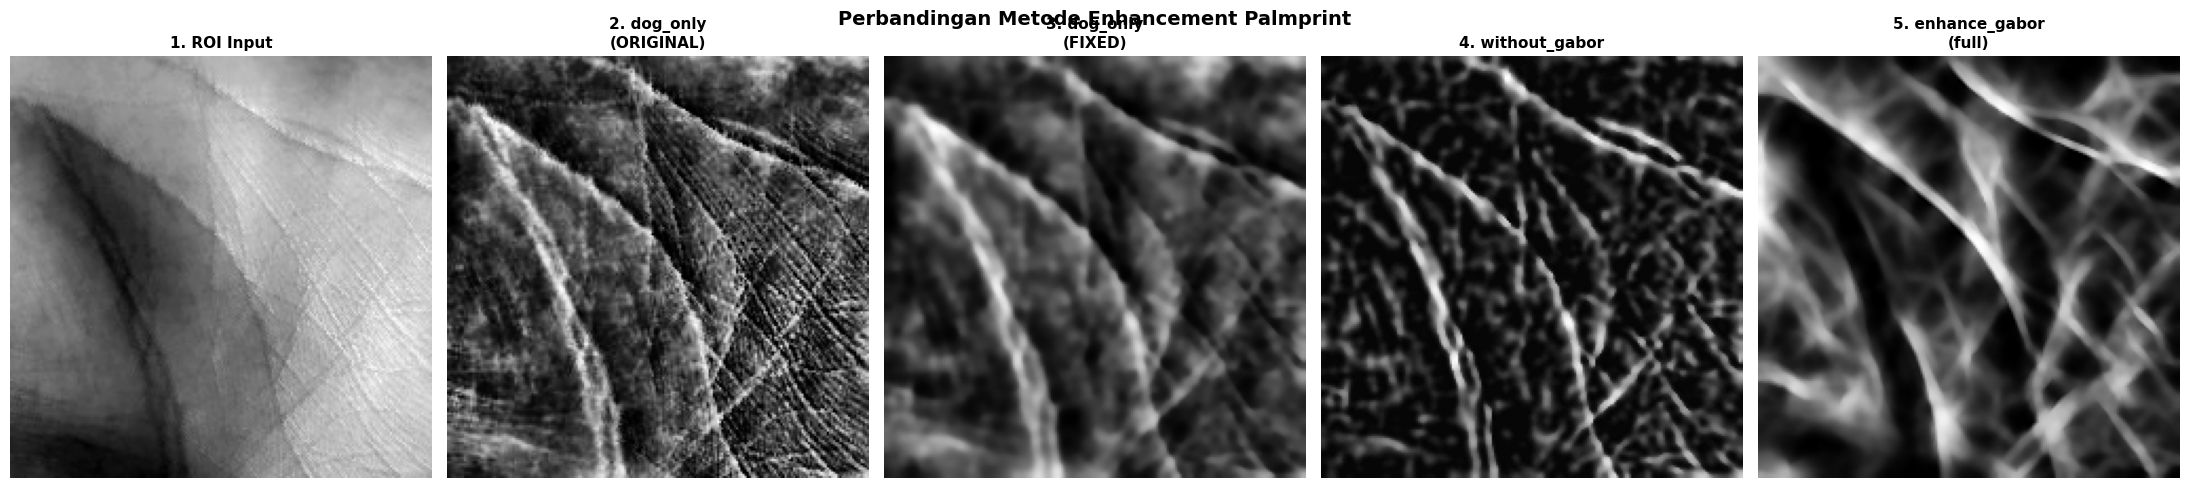

In [21]:
# ============================================================
# JALANKAN SEMUA METODE & BANDINGKAN
# ============================================================
results = {
    "1. ROI Input": roi_gray,
    "2. dog_only\n(ORIGINAL)": enhance_dog_only_original(roi_gray),
    "3. dog_only\n(FIXED)": enhance_dog_only_fixed(roi_gray),
    "4. without_gabor": enhance_without_gabor(roi_gray),
    "5. enhance_gabor\n(full)": enhance_gabor(roi_gray),
}

fig, axes = plt.subplots(1, 5, figsize=(22, 5))
fig.suptitle("Perbandingan Metode Enhancement Palmprint", fontsize=14, fontweight="bold")

for ax, (title, img) in zip(axes, results.items()):
    ax.imshow(img, cmap="gray")
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.axis("off")

plt.tight_layout()
plt.show()

In [22]:
# ============================================================
# METRIK NOISE (Laplacian variance) - proxy kekasaran gambar
# Semakin tinggi -> semakin banyak noise/tekstur kasar
# ============================================================
for title, img in results.items():
    lap_var = cv2.Laplacian(img, cv2.CV_64F).var()
    print(f"{title.replace(chr(10), ' ')}: Laplacian variance = {lap_var:.1f}")

1. ROI Input: Laplacian variance = 111.3
2. dog_only (ORIGINAL): Laplacian variance = 6029.0
3. dog_only (FIXED): Laplacian variance = 84.1
4. without_gabor: Laplacian variance = 182.6
5. enhance_gabor (full): Laplacian variance = 224.4


In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.feature import hog

# ── Konfigurasi (sama dengan extractor.py) ──
ROI_SIZE = 200
IMAGE_SIZE = 96
HOG_ORIENT = 12
HOG_PIXELS = 8
HOG_CELLS = 2
GABOR_GAMMA = 0.5
GABOR_THETAS = [i * np.pi / 8 for i in range(8)]
GABOR_SCALES = [
    (21, 1.5, 5.0),
    (31, 2.0, 8.0),
    (31, 3.0, 12.0),
    (31, 4.0, 16.0),
]


# =========================================================
# FUNGSI ENHANCEMENT (sama seperti notebook sebelumnya)
# =========================================================
def normalize_illumination_original(img_gray):
    img_f = img_gray.astype(np.float32)
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=0.5)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=12.0)
    dog = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_dog_only_original(img_gray):
    dog = normalize_illumination_original(img_gray)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    clahe_out = clahe.apply(dog)
    clahe_out = cv2.bitwise_not(clahe_out)
    gamma = 1.8
    lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    result = cv2.LUT(clahe_out, lut)
    blur = cv2.GaussianBlur(result, (0, 0), sigmaX=1.0)
    result = cv2.addWeighted(result, 1.4, blur, -0.4, 0)
    return result


def normalize_illumination_fixed(img_gray):
    img_f = img_gray.astype(np.float32)
    g_small = cv2.GaussianBlur(img_f, (0, 0), sigmaX=1.5)
    g_large = cv2.GaussianBlur(img_f, (0, 0), sigmaX=12.0)
    dog = g_small - g_large
    return cv2.normalize(dog, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)


def enhance_gabor(img_gray, use_dog=True):
    dog_original = normalize_illumination_fixed(img_gray)
    if use_dog:
        img_gray = dog_original.copy()

    kernel_th = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))
    tophat = cv2.morphologyEx(img_gray, cv2.MORPH_TOPHAT, kernel_th)
    tophat_boosted = cv2.multiply(tophat, np.array([2.0]))
    img_gray = cv2.add(img_gray, tophat_boosted.astype(np.uint8))

    all_responses = []
    for ksize, sigma, lambd in GABOR_SCALES:
        for theta in GABOR_THETAS:
            kernel = cv2.getGaborKernel(
                ksize=(ksize, ksize), sigma=sigma, theta=theta,
                lambd=lambd, gamma=GABOR_GAMMA, psi=0, ktype=cv2.CV_32F,
            )
            resp = cv2.filter2D(img_gray.astype(np.float32), cv2.CV_32F, kernel)
            all_responses.append(np.abs(resp))

    gabor_max = np.max(all_responses, axis=0)
    gabor_mean = np.mean(all_responses, axis=0)
    gabor_combined = 0.85 * gabor_max + 0.15 * gabor_mean
    gabor_out = cv2.normalize(gabor_combined, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

    clahe = cv2.createCLAHE(clipLimit=2.5, tileGridSize=(6, 6))
    clahe_out = clahe.apply(gabor_out)

    clahe_dog = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    dog_enhanced = clahe_dog.apply(dog_original)
    blended = cv2.addWeighted(clahe_out, 0.75, dog_enhanced, 0.25, 0)

    gamma = 2.2
    lut = np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)
    blended = cv2.LUT(blended, lut)

    blended = cv2.bilateralFilter(blended, d=5, sigmaColor=20, sigmaSpace=20)

    blur = cv2.GaussianBlur(blended, (0, 0), sigmaX=1.5)
    result = cv2.addWeighted(blended, 1.6, blur, -0.6, 0)
    return result


def enhance_without_gabor(img_gray):
    dog = normalize_illumination_fixed(img_gray)
    kernel_small = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    kernel_large = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (13, 13))
    blackhat_small = cv2.morphologyEx(dog, cv2.MORPH_BLACKHAT, kernel_small)
    blackhat_large = cv2.morphologyEx(dog, cv2.MORPH_BLACKHAT, kernel_large)
    blackhat = cv2.addWeighted(blackhat_small, 0.6, blackhat_large, 0.4, 0)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    result = clahe.apply(blackhat)
    result = cv2.bilateralFilter(result, d=5, sigmaColor=30, sigmaSpace=30)
    blur = cv2.GaussianBlur(result, (0, 0), sigmaX=1.0)
    result = cv2.addWeighted(result, 1.5, blur, -0.5, 0)
    return result


# =========================================================
# SIMULASI VARIASI CAPTURE (genuine pair augmentation)
# Simulasikan kondisi real-world: shift posisi kecil,
# variasi brightness, noise sensor kamera
# =========================================================
def simulate_capture_variation(img_gray, seed):
    rng = np.random.RandomState(seed)
    h, w = img_gray.shape

    # 1. Shift posisi kecil (misalignment ROI, umum terjadi di mobile)
    dx, dy = rng.randint(-4, 5), rng.randint(-4, 5)
    M = np.float32([[1, 0, dx], [0, 1, dy]])
    shifted = cv2.warpAffine(img_gray, M, (w, h), borderMode=cv2.BORDER_REFLECT)

    # 2. Variasi brightness/kontras (beda kondisi cahaya)
    alpha = rng.uniform(0.85, 1.15)  # kontras
    beta = rng.uniform(-15, 15)      # brightness
    adjusted = cv2.convertScaleAbs(shifted, alpha=alpha, beta=beta)

    # 3. Noise sensor kamera (gaussian noise ringan)
    noise = rng.normal(0, 4, (h, w)).astype(np.float32)
    noisy = np.clip(adjusted.astype(np.float32) + noise, 0, 255).astype(np.uint8)

    return noisy


def compute_hog_feature(img_gray):
    """Resize ke IMAGE_SIZE lalu hitung HOG descriptor."""
    resized = cv2.resize(img_gray, (IMAGE_SIZE, IMAGE_SIZE), interpolation=cv2.INTER_AREA)
    features = hog(
        resized,
        orientations=HOG_ORIENT,
        pixels_per_cell=(HOG_PIXELS, HOG_PIXELS),
        cells_per_block=(HOG_CELLS, HOG_CELLS),
        block_norm="L2-Hys",
        feature_vector=True,
    )
    return features


def cosine_sim(a, b):
    a = a / (np.linalg.norm(a) + 1e-9)
    b = b / (np.linalg.norm(b) + 1e-9)
    return float(np.dot(a, b))


# =========================================================
# LOAD ROI: "orang A" dan "orang B" (sintetis, beda struktur garis)
# =========================================================
roi_A = cv2.imread("debug_roi_155122_542083.jpg")
roi_A = cv2.cvtColor(roi_A, cv2.COLOR_BGR2GRAY)
roi_A = cv2.resize(roi_A, (ROI_SIZE, ROI_SIZE), interpolation=cv2.INTER_AREA)

roi_B = cv2.imread("debug_roi_155122_542083.jpg")
roi_B = cv2.cvtColor(roi_B, cv2.COLOR_BGR2GRAY)
roi_B = cv2.resize(roi_B, (ROI_SIZE, ROI_SIZE), interpolation=cv2.INTER_AREA)

print("ROI A shape:", roi_A.shape, " | ROI B shape:", roi_B.shape)

methods = {
    "dog_only (ORIGINAL)": enhance_dog_only_original,
    "enhance_gabor (full)": enhance_gabor,
    "without_gabor": enhance_without_gabor,
}

N_CAPTURES = 6  # jumlah simulasi capture per orang

results_summary = {}

for method_name, method_fn in methods.items():
    # ── Genuine pair: ROI A vs variasi capture ROI A lainnya ──
    genuine_scores = []
    base_capture_A = method_fn(roi_A)
    feat_base_A = compute_hog_feature(base_capture_A)

    for seed in range(N_CAPTURES):
        varied_A = simulate_capture_variation(roi_A, seed=seed)
        enhanced_varied_A = method_fn(varied_A)
        feat_varied_A = compute_hog_feature(enhanced_varied_A)
        sim = cosine_sim(feat_base_A, feat_varied_A)
        genuine_scores.append(sim)

    # ── Impostor pair: ROI A (base) vs ROI B (orang lain) + variasinya ──
    impostor_scores = []
    base_capture_B = method_fn(roi_B)
    feat_base_B = compute_hog_feature(base_capture_B)
    sim_AB = cosine_sim(feat_base_A, feat_base_B)
    impostor_scores.append(sim_AB)

    for seed in range(N_CAPTURES):
        varied_B = simulate_capture_variation(roi_B, seed=seed + 100)
        enhanced_varied_B = method_fn(varied_B)
        feat_varied_B = compute_hog_feature(enhanced_varied_B)
        sim = cosine_sim(feat_base_A, feat_varied_B)
        impostor_scores.append(sim)

    genuine_mean = np.mean(genuine_scores)
    genuine_std = np.std(genuine_scores)
    impostor_mean = np.mean(impostor_scores)
    impostor_std = np.std(impostor_scores)
    margin = genuine_mean - impostor_mean

    results_summary[method_name] = {
        "genuine_scores": genuine_scores,
        "impostor_scores": impostor_scores,
        "genuine_mean": genuine_mean,
        "genuine_std": genuine_std,
        "impostor_mean": impostor_mean,
        "impostor_std": impostor_std,
        "margin": margin,
    }

    print(f"\n=== {method_name} ===")
    print(f"  Genuine  cosine sim : mean={genuine_mean:.4f}  std={genuine_std:.4f}")
    print(f"  Impostor cosine sim : mean={impostor_mean:.4f}  std={impostor_std:.4f}")
    print(f"  Margin (genuine - impostor) : {margin:.4f}")

# =========================================================
# VISUALISASI: distribusi skor genuine vs impostor per metode
# =========================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Distribusi Cosine Similarity: Genuine vs Impostor Pair", fontsize=14, fontweight="bold")

for ax, (method_name, data) in zip(axes, results_summary.items()):
    ax.hist(data["genuine_scores"], bins=8, alpha=0.6, label="Genuine pair", color="green")
    ax.hist(data["impostor_scores"], bins=8, alpha=0.6, label="Impostor pair", color="red")
    ax.axvline(data["genuine_mean"], color="green", linestyle="--", linewidth=1.5)
    ax.axvline(data["impostor_mean"], color="red", linestyle="--", linewidth=1.5)
    ax.set_title(f"{method_name}\nMargin = {data['margin']:.3f}", fontsize=11, fontweight="bold")
    ax.set_xlabel("Cosine similarity")
    ax.set_ylabel("Frekuensi")
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.savefig("/home/claude/work/cosine_similarity_comparison.png", dpi=130, bbox_inches="tight")
print("\nSaved cosine_similarity_comparison.png")

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\color.cpp:199: error: (-215:Assertion failed) !_src.empty() in function 'cv::cvtColor'
